In [ ]:
import time
import json
import os
import sys
import math
sys.path.append(os.path.dirname(os.getcwd()))
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm
from matplotlib.colors import Normalize
from PIL import Image

from pc import PS
from modules import ADC,DAC,CHIP
from command import CMD,CmdData,Packet
from command.singleCmdInfo import *

from util import plot_v_cond,plot_cond,show_crossbar,DataLoader

from network.layer import Layer

In [ ]:
chip=CHIP(PS(host="192.168.1.10", port = 7, debug=0),init=True)
chip.set_device_cfg(deviceType=0,IsNew32=False)
chip.adc.set_gap(adc_cs_gap=90,adc_first_gap=100,adc_last_gap=100)
chip.adc.set_gain_resistor(big_resistance=10e3,small_resistance=200)
chip.clk_manager.set_cyc(10, 10,delay3=50)
chip.add_compiler("../compiler/code/")
chip.compensation.initop("../chip_data/chip6_/")

### 1. 单列线性补偿

In [ ]:
v,c,r = chip.read4(crossbar=np.ones((256,256)),row_index=None,col_index=None,read_voltage=0.1,tg=5,gain=1,sub_base=True,from_row=True,split_type=0,row_type=0,col_type=0)
c = chip.compensation.compensation_point(r,from_row=True,return_type=0,)
# plot_cond(c,vmax=1000)

In [ ]:
compensation_para:dict={
"value":0.875,
"real_mean":550,
"odd_offset":0,
"even_offset":0,
"odd_mult":1,
"even_mult":1,
"all_mult":1,
"add_wire":False
}

c = chip.compensation.compensation_point(r,from_row=True,return_type=0,)

In [ ]:
col = 10
select_num,total_num = 75,100


random_times = 100
real_res = np.zeros(random_times)
expected_res = np.zeros(random_times)
for i in range(random_times):
    rows_index = np.random.choice(total_num, select_num, replace=False)
    res = chip.read4(crossbar=np.ones((256,256)),row_index=rows_index,col_index=[col],read_voltage=0.1,tg=5,gain=3,sub_base=True,from_row=True,split_type=3,row_type=0,col_type=0)
    cond = chip.compensation.compensation_forward(rows_index,res[2],from_row=True,return_type=0,compensation_para=compensation_para)
    # print(np.max(res[0]))
    expected_res[i]=np.sum(c[rows_index,col])
    real_res[i]=cond[col]

In [ ]:
coefficients = np.polyfit(real_res, expected_res, 1)
print("拟合系数:", coefficients[0],coefficients[1])

# 拟合的线性函数
def linear_fit(x):
    return coefficients[0] * x + coefficients[1]

# 计算拟合的 y 值
y_fit = linear_fit(real_res)

plt.figure(figsize=(12, 5))

plt.subplot(1,2,1)
plt.title(f"random row count = {select_num}")
plt.plot(expected_res,label = "expected output")
plt.plot(real_res,label = "actual output")
plt.plot(y_fit,label = "fit output")
plt.ylabel("uS")
plt.xlabel("times")
plt.legend()

plt.subplot(1,2,2)
plt.plot(np.zeros(random_times))
plt.plot(real_res/expected_res-1,label = "actual output/expected output")
plt.plot(y_fit/expected_res-1,label = "fit output/expected output")
plt.ylabel("100%")
plt.xlabel("times")
plt.legend()
plt.title(f"random row count = {select_num}")
plt.show()

### 2. 矩阵求逆补偿

In [37]:
v,c,r = chip.read4(crossbar=np.ones((256,256)),row_index=None,col_index=None,read_voltage=0.1,tg=5,gain=1,sub_base=True,from_row=True,split_type=0,row_type=0,col_type=0)
c = chip.compensation.compensation_point(r,from_row=True,return_type=0)

In [ ]:
col_index = [i for i in range(10,20)]
random_times = 5000
real_res = np.zeros((random_times,len(col_index)))
expected_res = np.zeros((random_times,len(col_index)))
for i in range(random_times):
    # 这次的输入是多少行
    row_num = np.random.choice(total_num, 1, replace=False)[0]
    while row_num ==0 :
        row_num = np.random.choice(total_num, 1, replace=False)[0]
    # 随机选row_num行作为输入
    rows_index = np.random.choice(total_num, row_num, replace=False)

    res = chip.read4(crossbar=np.ones((256,256)),row_index=rows_index,col_index=col_index,read_voltage=0.1,tg=5,gain=3,sub_base=True,from_row=True,split_type=4,row_type=0,col_type=0)
    cond = chip.compensation.compensation_forward(rows_index,res[2],from_row=True,return_type=0,compensation_para=compensation_para)
    # print(np.max(res[0]))
    pos = np.ix_(rows_index,col_index)
    # print(np.sum(c[pos],axis=0).shape)
    expected_res[i,:]=np.sum(c[pos],axis=0)
    real_res[i,:]=cond[col_index]

ValueError: could not broadcast input array from shape (31,) into shape (10,)

In [90]:
rows_index = [i for i in range(10,20)]
random_times = 5000
real_res = np.zeros((random_times,len(rows_index)))
expected_res = np.zeros((random_times,len(rows_index)))
for i in range(random_times):
    # 这次的输入是多少行
    row_num = np.random.choice(total_num, 1, replace=False)[0]
    while row_num ==0 :
        row_num = np.random.choice(total_num, 1, replace=False)[0]
    # 随机选row_num行作为输入
    col_index = np.random.choice(total_num, row_num, replace=False)

    res = chip.read4(crossbar=np.ones((256,256)),row_index=rows_index,col_index=col_index,read_voltage=0.1,tg=5,gain=3,sub_base=True,from_row=True,split_type=4,row_type=0,col_type=0)
    cond = chip.compensation.compensation_forward(rows_index,res[2],from_row=True,return_type=0,compensation_para=compensation_para)
    # print(np.max(res[0]))
    pos = np.ix_(rows_index,col_index)
    # print(np.sum(c[pos],axis=0).shape)
    expected_res[i,:]=np.sum(c[pos],axis=1)
    real_res[i,:]=cond[rows_index]

In [91]:
A_pinv = np.linalg.pinv(real_res)
W_pinv = np.dot(A_pinv,expected_res)
expected_res2 = np.dot(expected_res ,W_pinv)

data = expected_res2/expected_res-1
x = [i for i in range(10)]

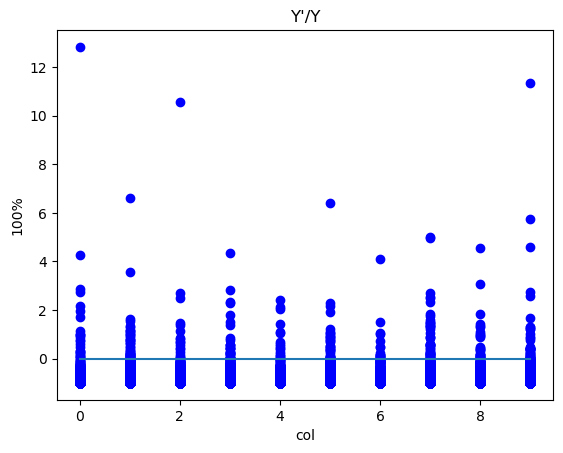

In [92]:
data = real_res/expected_res-1
data[data<-2] = -2
x = [i for i in range(10)]
for i in range(5000):
    plt.scatter(x, data[i], color='blue')
plt.plot(np.zeros(10))
# 添加标题和标签
plt.title("Y\'/Y")
plt.ylabel("100%")
plt.xlabel("col")

# 添加图例
# plt.legend()

# 显示图表
plt.show()

In [79]:
print(np.sum(np.abs(data)>0.1)/50000)

0.39176


### 3. 线阻补偿

In [ ]:
v,c,r = chip.read4(crossbar=np.ones((256,256)),row_index=None,col_index=None,read_voltage=0.1,tg=5,gain=1,sub_base=True,from_row=True,split_type=0,row_type=0,col_type=0)
c = chip.compensation.compensation_point(r,from_row=True,return_type=0)